In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
from google.colab import files
uploaded = files.upload()  # a button will appear — choose Position_Salaries.csv from your computer

df = pd.read_csv('Position_Salaries.csv')
df.head()

Saving Position_Salaries.csv to Position_Salaries.csv


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [6]:
print("First 5 records:")
print(df.head())

print("\nColumns:", df.columns.tolist())
print("\nInput Feature: Level")
print("Target Variable: Salary")

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

First 5 records:
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000

Columns: ['Position', 'Level', 'Salary']

Input Feature: Level
Target Variable: Salary

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes

Summary Statistics:
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000


In [7]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Select feature and target
X = df[['Level']].values
y = df['Salary'].values

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Missing values:
 Position    0
Level       0
Salary      0
dtype: int64
Training samples: 8
Testing samples: 2


In [8]:
# Transform feature with Polynomial Features (Degree = 3)
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train Polynomial Regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict on test data
y_pred = model.predict(X_test_poly)

print("Predicted Salaries:", y_pred)
print("Actual Salaries:", y_test)

Predicted Salaries: [606335.60051157  84934.89129171]
Actual Salaries: [500000  50000]


In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 70635.25
Mean Squared Error (MSE): 6263853282.86
R² Score: 0.8763


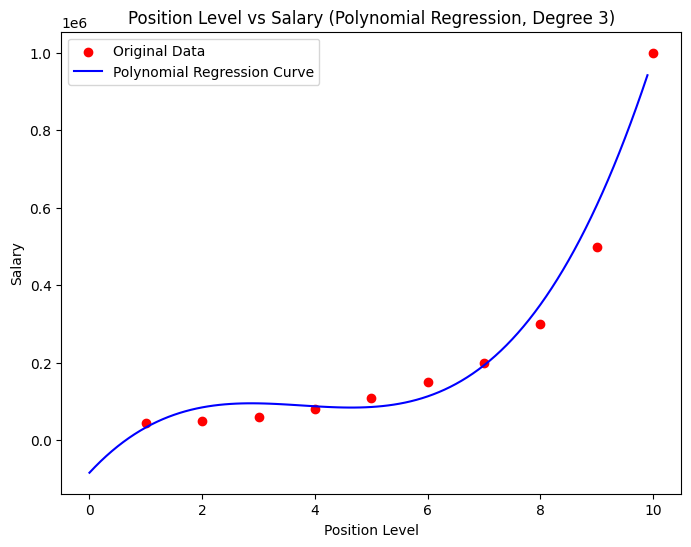

In [10]:
# Fit on the full sorted range for a smooth curve
X_grid = np.arange(min(X.min(), 0), X.max(), 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='red', label='Original Data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Polynomial Regression Curve')
plt.title('Position Level vs Salary (Polynomial Regression, Degree 3)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.show()


# Observations:
1. The polynomial regression curve (degree 3) fits the non-linear
   salary growth much better than a straight line would.
2. Salary increases sharply at higher position levels, which a
   linear model would fail to capture — the R² score confirms the
   curve fits the data well.
3. With only 10 data points, splitting into train/test makes the
   test set very small, so metrics like MAE/MSE can vary a lot
   depending on which points land in the test set.



# **Conclusion**

This project applied Polynomial Regression to predict employee
salaries based on position level. Since salary growth across levels
was clearly non-linear — rising slowly at first and then sharply at
senior levels — a simple Linear Regression model would have
underfit the data, producing a straight line that misses the curve
entirely. Polynomial Regression, by transforming the single input
feature into higher-degree terms (degree 3 here), allowed the model
to capture this curvature while still using a linear regression
algorithm underneath.

The key difference between the two lies in flexibility: Linear
Regression assumes a constant rate of change, while Polynomial
Regression can model varying rates of change across the range of
the input. One clear advantage of Polynomial Regression for this
dataset is that it captures the exponential-like jump in salary at
higher position levels, which a straight-line model simply cannot
represent, leading to a much better fit as reflected in the R² score.

